# 第 18 章公开汽车价格回归
UCI Automobile，1985 历史资料。先运行 examples/run_regression.py 导出图片。保留原表量纲，未换算币种。

In [1]:
from examples.regression_core import prepare_data, run_experiment, metrics, FEATURES
from IPython.display import Image, display
clean, rejected, cleaning = prepare_data()
print(cleaning)
print(rejected[['sample_id', 'missing_fields']].to_string(index=False))

{'raw_rows': 205, 'complete_rows': 199, 'rejected_rows': 6, 'missing_counts_in_selected_fields': {'engine_size': 0, 'curb_weight': 0, 'horsepower': 2, 'price': 4}, 'policy': '只删除本章所选特征或价格缺失的行，未填补标签；保留拒绝表', 'selected_features': ['engine_size', 'curb_weight', 'horsepower']}
sample_id missing_fields
 auto-009          price
 auto-044          price
 auto-045          price
 auto-129          price
 auto-130     horsepower
 auto-131     horsepower


## 固定划分与均值基线
三个模型预先指定，在同一训练与测试集上比较，不按测试分数反复选特征。

In [2]:
models, train, test, summary = run_experiment(clean)
print('训练/测试', len(train), len(test))
print('编号无交集', set(train.sample_id).isdisjoint(test.sample_id))
print('训练均价与基线', train.price.mean(), summary['parameters']['baseline'])

训练/测试 159 40
编号无交集 True
训练均价与基线 12386.308176100629 {'constant': 12386.308176100629}


## 单特征与多特征参数
系数对应字段次序。数值是原表单位下的条件关系，不是因果效应。

{'single': {'intercept': -6149.35945075567, 'coefficients': {'engine_size': 150.55022234726968}}, 'multi': {'intercept': -11685.468026667662, 'coefficients': {'engine_size': 78.77772245508308, 'curb_weight': 4.162663645065965, 'horsepower': 39.1564306403424}}, 'baseline': {'constant': 12386.308176100629}}


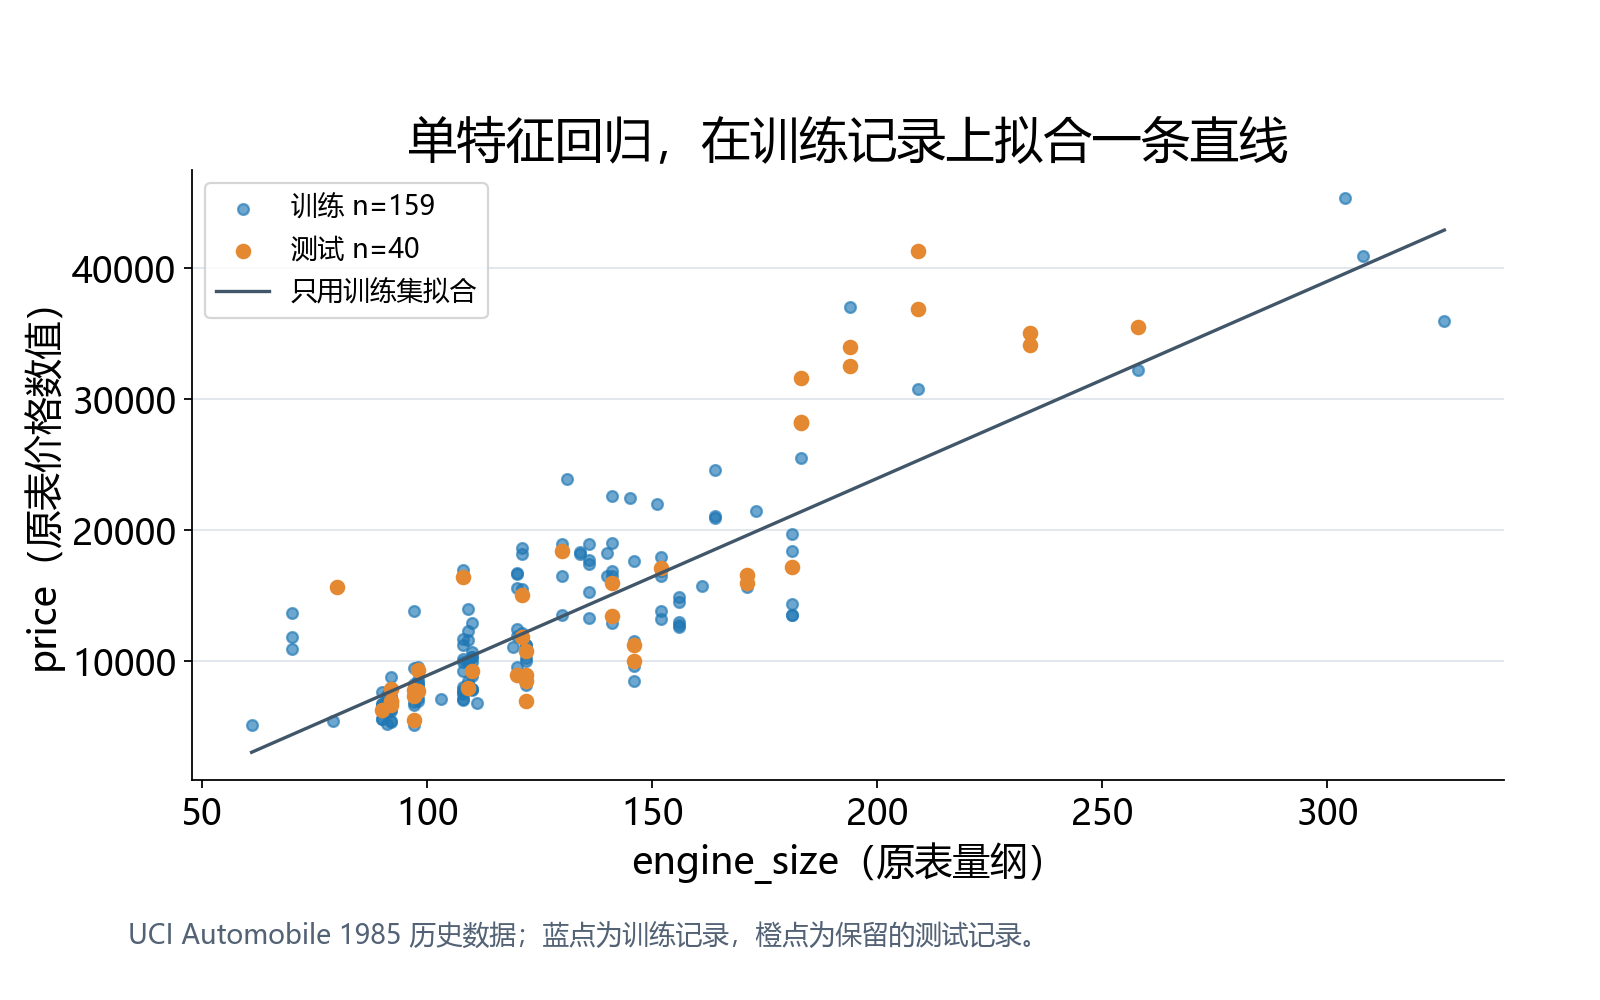

In [3]:
print(summary['parameters'])
display(Image(filename='assets/single-feature-fit.png'))

## 训练结果与测试结果都记录
MAE 与 RMSE 沿用目标的原表量纲，R2 无量纲。

baseline train {'MAE': 5023.3233, 'RMSE': 6868.4862, 'R2': 0.0}
baseline test {'MAE': 8316.0, 'RMSE': 11456.2568, 'R2': -0.1608}
single train {'MAE': 2532.0026, 'RMSE': 3432.2987, 'R2': 0.7503}
single test {'MAE': 4107.6321, 'RMSE': 5515.4152, 'R2': 0.7309}
multi train {'MAE': 2111.8371, 'RMSE': 3053.2073, 'R2': 0.8024}
multi test {'MAE': 3615.8953, 'RMSE': 4999.5075, 'R2': 0.7789}


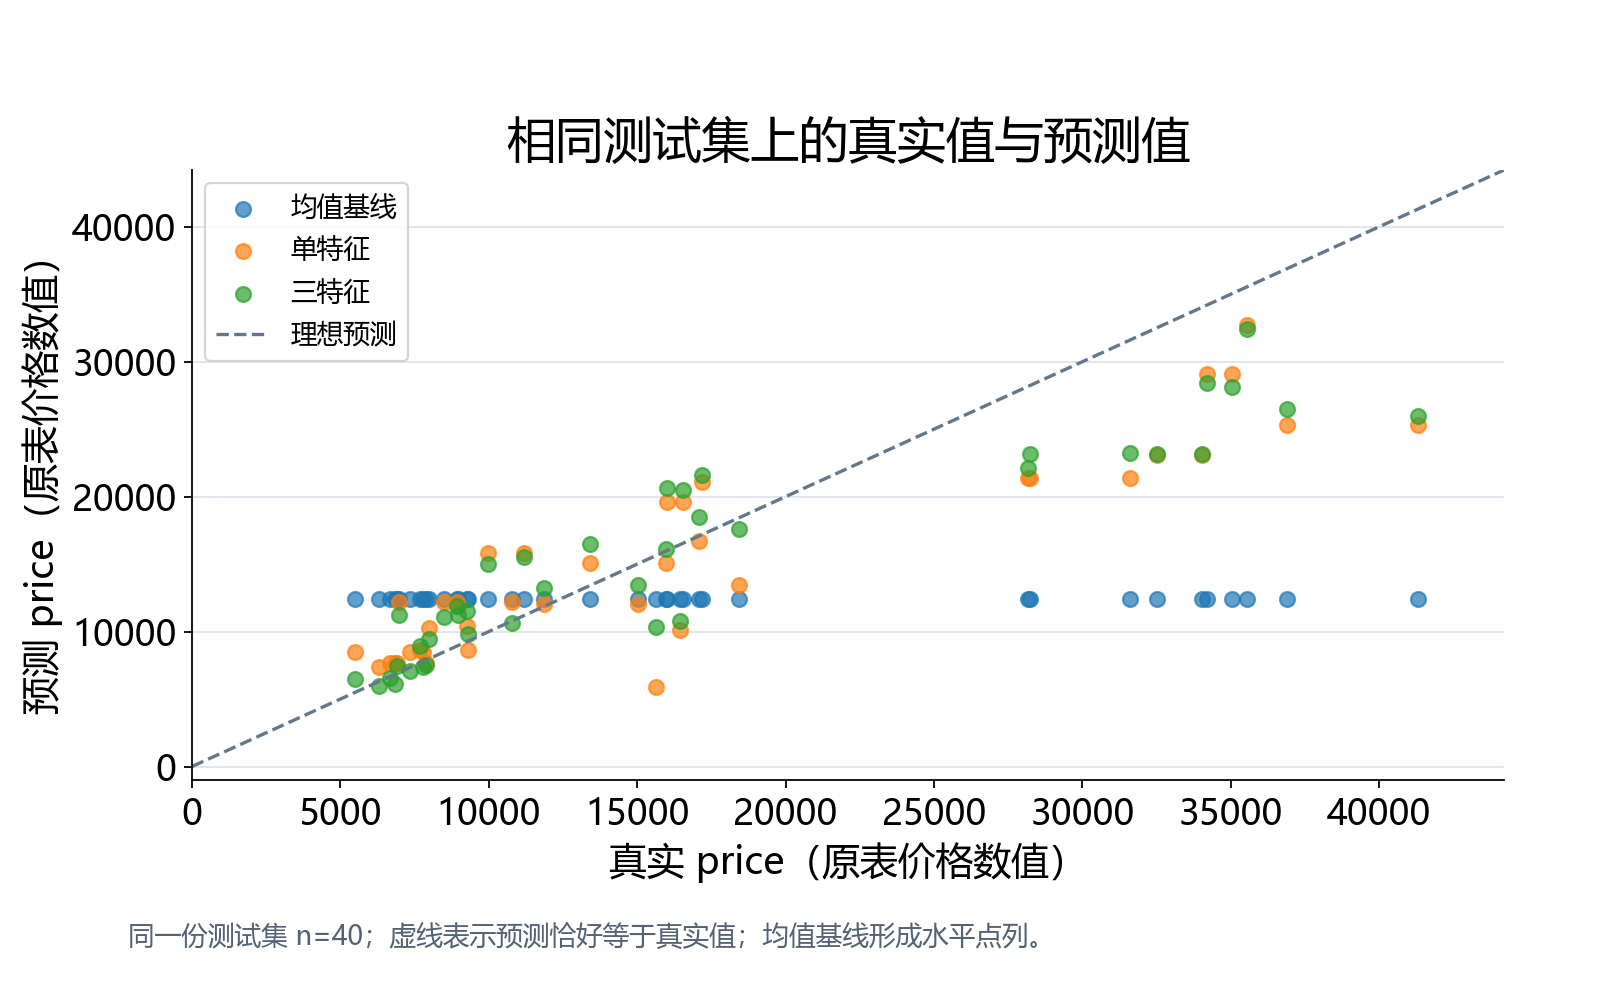

In [4]:
for name, scores in summary['scores'].items():
    for split in ['train', 'test']:
        print(name, split, {k: round(v, 4) for k, v in scores[split].items()})
display(Image(filename='assets/actual-vs-predicted.png'))

## 哪些记录误差大
残差采用真实值减预测值。正值为低估，负值为高估。

sample_id          make   price  multi_prediction  multi_residual
 auto-016           bmw 41315.0      25975.349463    15339.650537
 auto-127       porsche 34028.0      23175.092278    10852.907722
 auto-017           bmw 36880.0      26495.682419    10384.317581
 auto-126       porsche 32528.0      23175.092278     9352.907722
 auto-070 mercedes-benz 31600.0      23240.338093     8359.661907


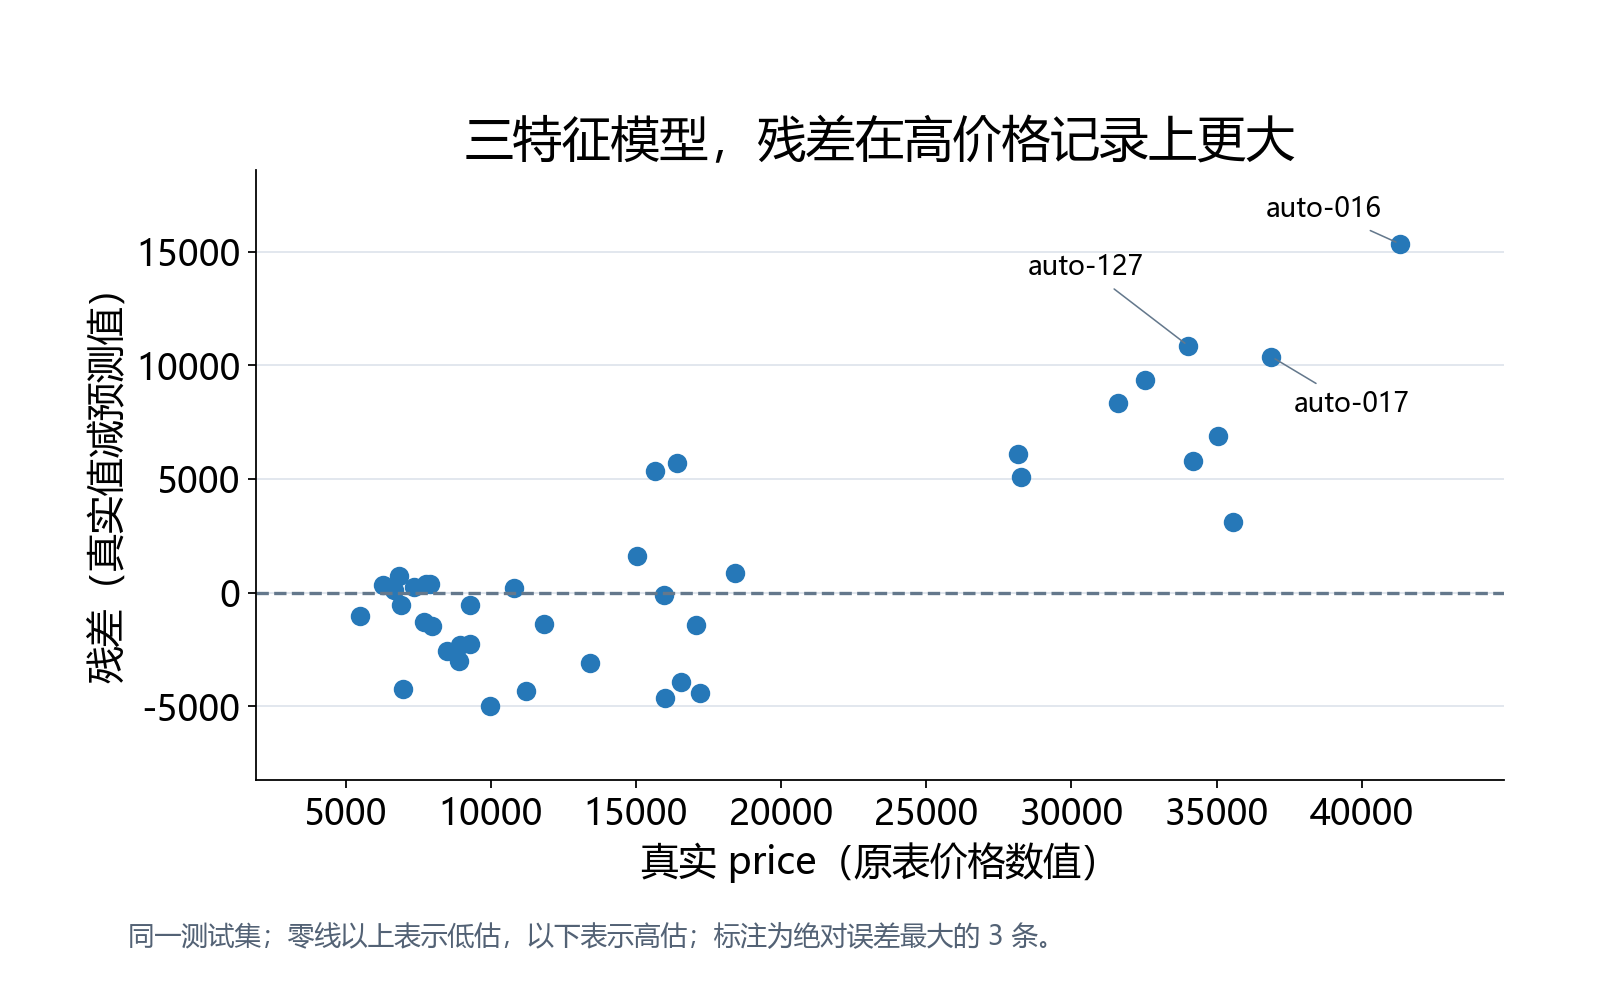

In [5]:
worst = test.sort_values('multi_absolute_error', ascending=False).head(5)
print(worst[['sample_id', 'make', 'price', 'multi_prediction', 'multi_residual']].to_string(index=False))
display(Image(filename='assets/multi-feature-residuals.png'))

## 用真实逐条误差核对指标
独立手算与工具输出比较。

In [6]:
import numpy as np
residual = test.price.to_numpy() - test.multi_prediction.to_numpy()
manual_mae = np.abs(residual).mean()
manual_rmse = np.sqrt((residual**2).mean())
manual_r2 = 1 - (residual**2).sum()/((test.price-test.price.mean())**2).sum()
print(manual_mae, manual_rmse, manual_r2)
np.testing.assert_allclose([manual_mae, manual_rmse, manual_r2], list(summary['scores']['multi']['test'].values()))

3615.895256463943 4999.50754735534 0.7789268897849286


## 独立练习
虚构两条预测，先手算误差。以下数字只用于指标练习。

In [7]:
actual = np.array([10000, 20000])
predicted = np.array([12000, 17000])
print(metrics(actual, predicted))
assert metrics(actual, predicted)['MAE'] == 2500

{'MAE': 2500.0, 'RMSE': 2549.5097567963926, 'R2': 0.74}
